In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional-looking plots
plt.style.use('default')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

In [76]:
file_path = '../data/raw/Road.csv'
df = pd.read_csv(file_path)

print(f"Original Dataset Shape: {df.shape}")
df.head()

Original Dataset Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## Basic Inspection

In [77]:
# Info (Data types and non-null counts)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

In [78]:
# Describe (Basic statistics)
print("--- Statistical Summary (Including Categoricals) ---")
display(df.describe(include='all').T.head(10)) # Displaying first 10 for readability

--- Statistical Summary (Including Categoricals) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time,12316,1074,15:30:00,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_week,12316,7,Friday,2041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_band_of_driver,12316,5,18-30,4271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex_of_driver,12316,3,Male,11437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Educational_level,11575,7,Junior high school,7619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_driver_relation,11737,4,Employee,9627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driving_experience,11487,7,5-10yr,3363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type_of_vehicle,11366,17,Automobile,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_of_vehicle,11834,4,Owner,10459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Service_year_of_vehicle,8388,6,Unknown,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Standardize Missing Values

In [79]:
missing_formats = ['na', 'unknown', 'Unknown', ' ', '', 'nan']
df.replace(missing_formats, np.nan, inplace=True)

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,NaN,NaN,NaN,NaN,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,No defect,Outside rural areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Going straight,NaN,NaN,NaN,NaN,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,NaN,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Escarpments,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Other,NaN,NaN,NaN,NaN,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,Office areas,Undivided Two way,Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,NaN,NaN,NaN,NaN,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


## Missing Value Analysis

In [80]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_percent
}).sort_values(by='Missing_Percentage', ascending=False)

missing_df.head(15)

,Missing_Count,Missing_Percentage
Service_year_of_vehicle,6811,55.302046
Age_band_of_casualty,4443,36.075024
Casualty_class,4443,36.075024
Sex_of_casualty,4443,36.075024
Casualty_severity,4443,36.075024
Defect_of_vehicle,4427,35.945112
Work_of_casuality,3217,26.120494
Fitness_of_casuality,2635,21.394933
Age_band_of_driver,1548,12.569016
Types_of_Junction,1078,8.752842


In [81]:
# Check if same rows are missing across multiple columns
missing_cols = missing_df[missing_df['Missing_Count'] > 0].index

df[missing_cols].isnull().sum(axis=1).value_counts().head()

1    2319
2    2007
5    1597
3    1372
4    1281
Name: count, dtype: int64

In [82]:
# Cardinality Check
df.nunique().sort_values(ascending=False)

Time                           1074
Cause_of_accident                19
Type_of_vehicle                  17
Area_accident_occured            13
Vehicle_movement                 12
Road_allignment                   9
Pedestrian_movement               9
Type_of_collision                 9
Weather_conditions                8
Number_of_casualties              8
Day_of_week                       7
Types_of_Junction                 7
Number_of_vehicles_involved       6
Lanes_or_Medians                  6
Work_of_casuality                 6
Driving_experience                6
Educational_level                 6
Service_year_of_vehicle           5
Road_surface_type                 5
Fitness_of_casuality              5
Age_band_of_casualty              5
Road_surface_conditions           4
Light_conditions                  4
Owner_of_vehicle                  4
Age_band_of_driver                4
Casualty_class                    3
Defect_of_vehicle                 3
Casualty_severity           

## Target Variable Analysis

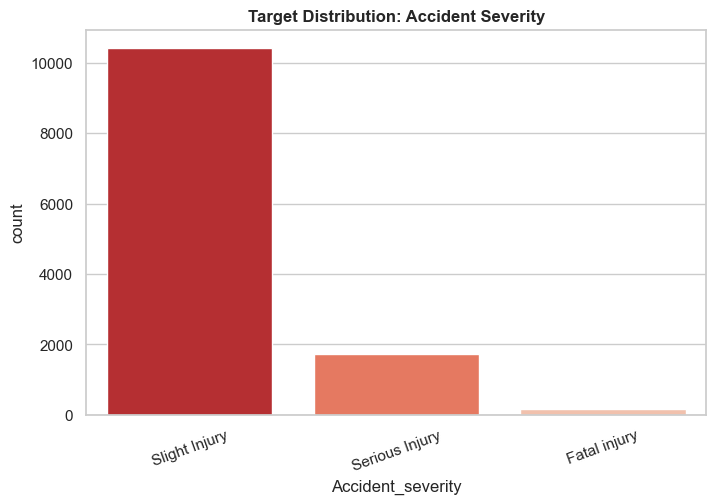

Accident_severity
Slight Injury     84.564794
Serious Injury    14.152322
Fatal injury       1.282884
Name: proportion, dtype: float64

In [83]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Accident_severity',
    order=df['Accident_severity'].value_counts().index,
    palette='Reds_r'
)

plt.title('Target Distribution: Accident Severity', fontweight='bold')
plt.xticks(rotation=20)
plt.show()

df['Accident_severity'].value_counts(normalize=True) * 100

## Time Feature Engineering

In [84]:
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Hour_of_Day'] = df['Time'].dt.hour

def categorize_time(hour):
    if pd.isnull(hour):
        return np.nan
    elif 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Hour_of_Day'].apply(categorize_time)

## Univariate Analysis (Categorical)


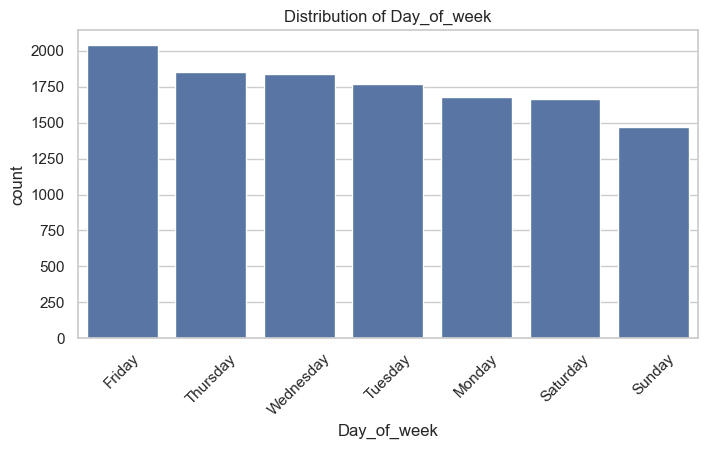

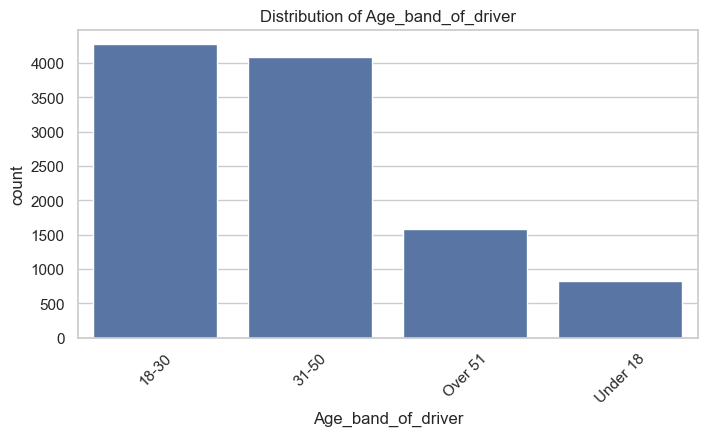

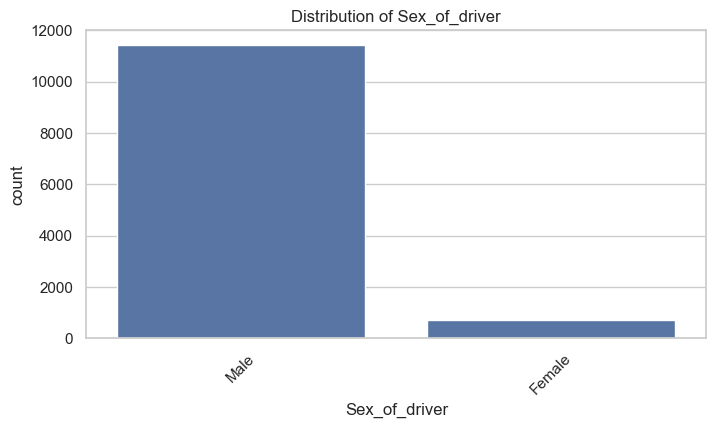

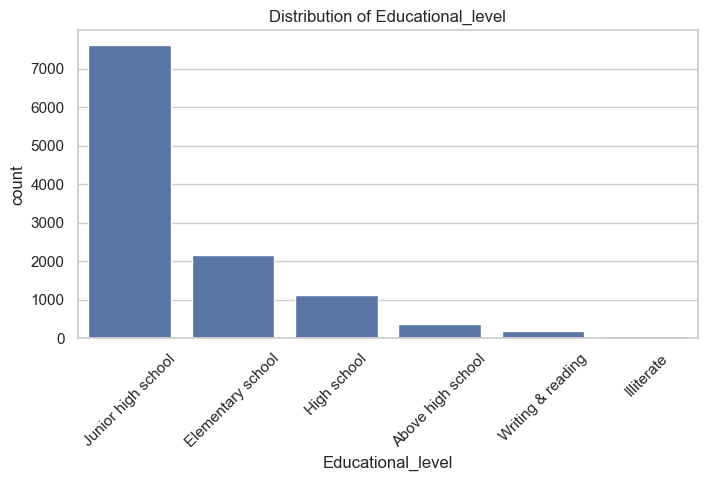

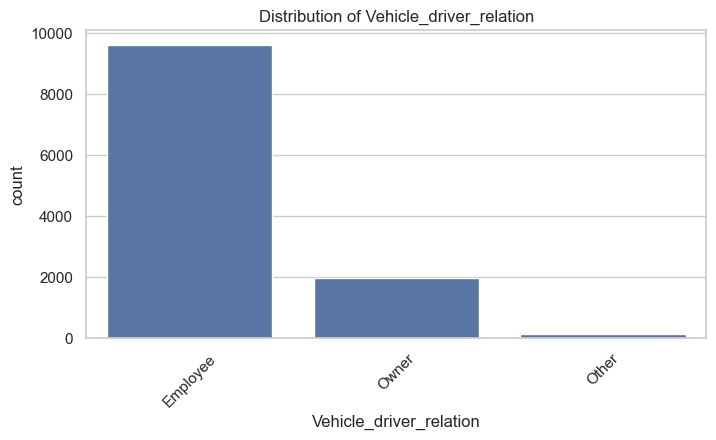

In [85]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols[:5]:  # limit for readability
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

## Univariate Analysis (Numerical)

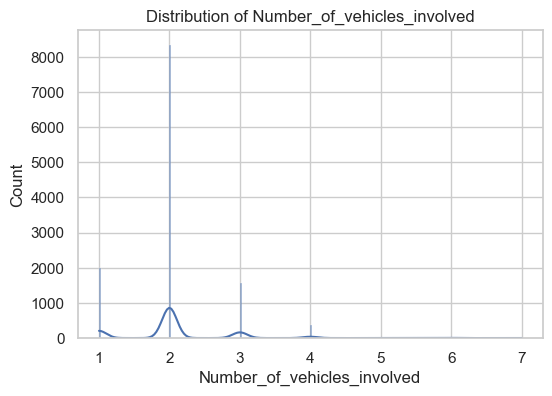

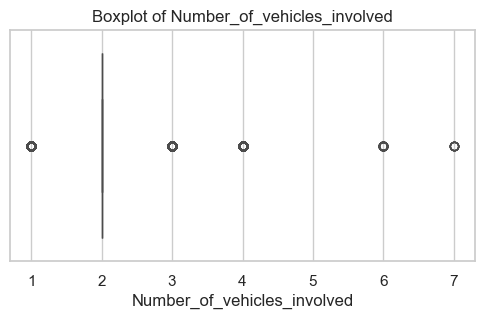

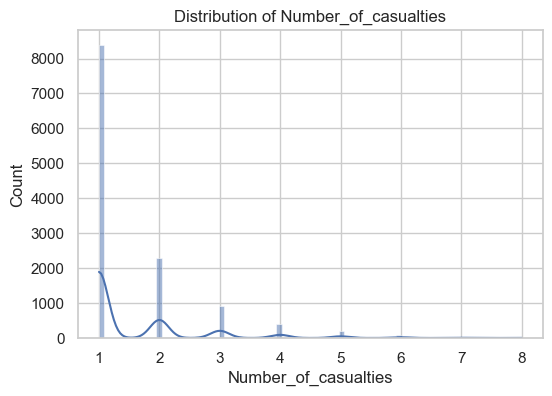

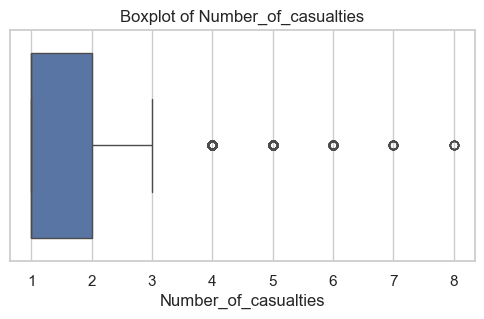

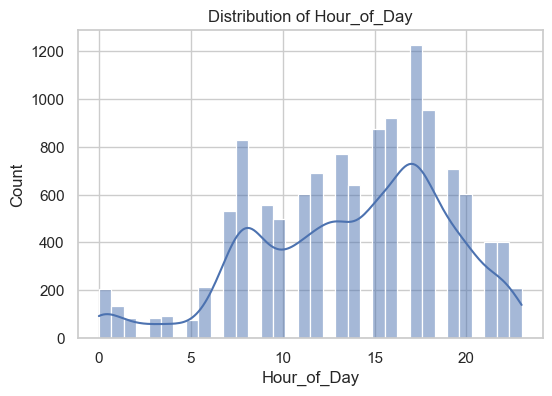

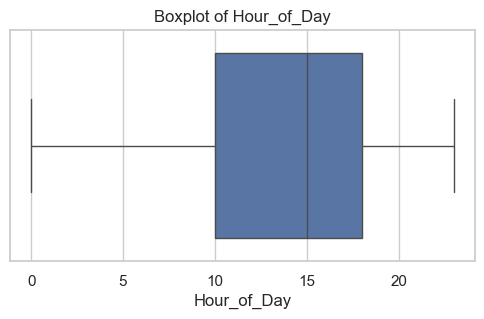

In [86]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Bivariate Analysis (Categorical vs Target)


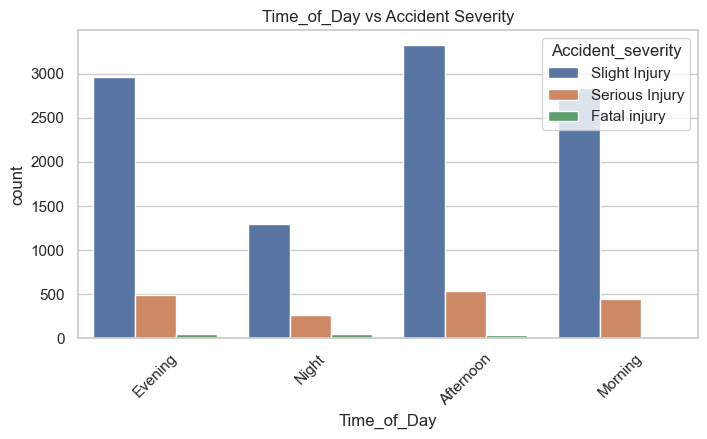

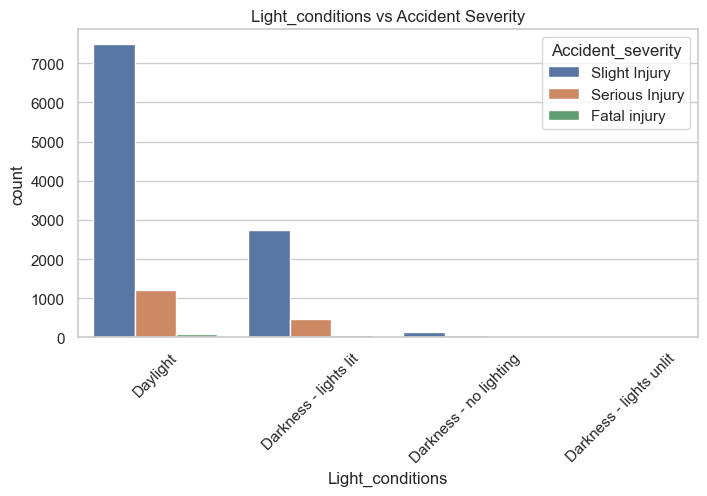

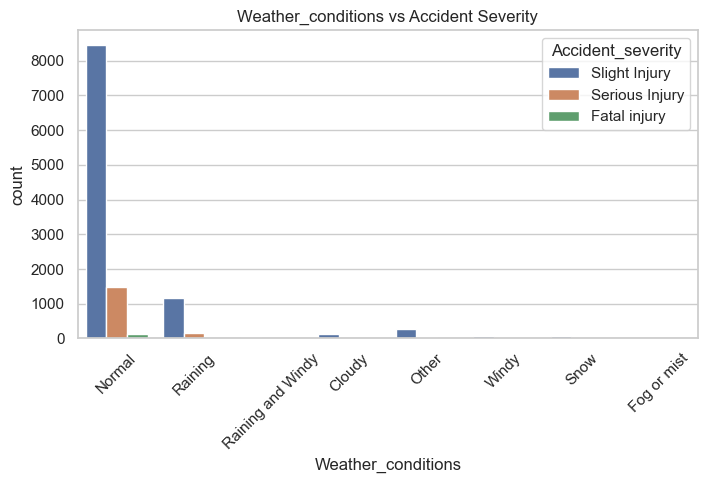

In [87]:
important_cols = ['Time_of_Day', 'Light_conditions', 'Weather_conditions']

for col in important_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Accident_severity')
    plt.title(f'{col} vs Accident Severity')
    plt.xticks(rotation=45)
    plt.show()

## Numerical vs Target

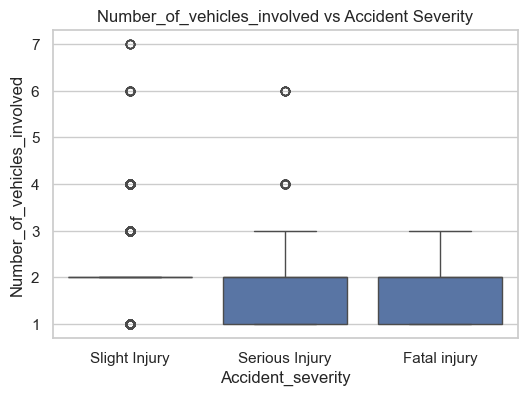

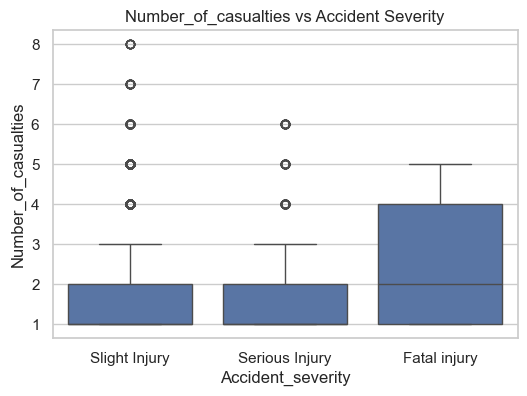

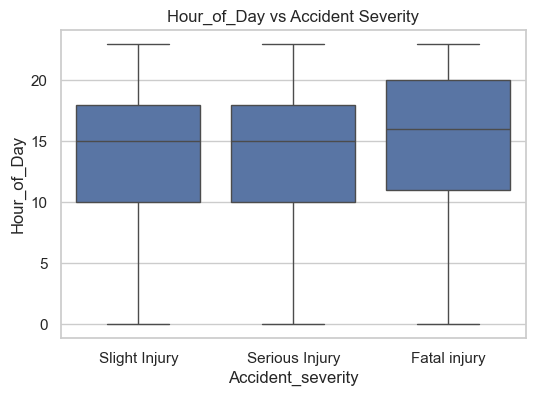

In [88]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Accident_severity', y=col, data=df)
    plt.title(f'{col} vs Accident Severity')
    plt.show()

## Correlation (Numerical)

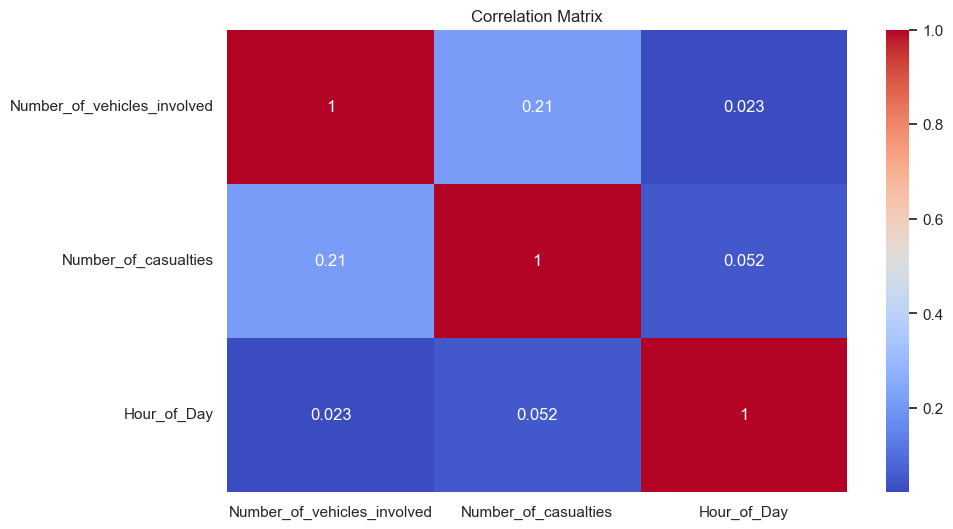

In [89]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Categorical Association (Cramer's V)

In [93]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

categorical_cols = df.select_dtypes(include='object').columns

# Create empty matrix
cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

# Fill matrix
for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

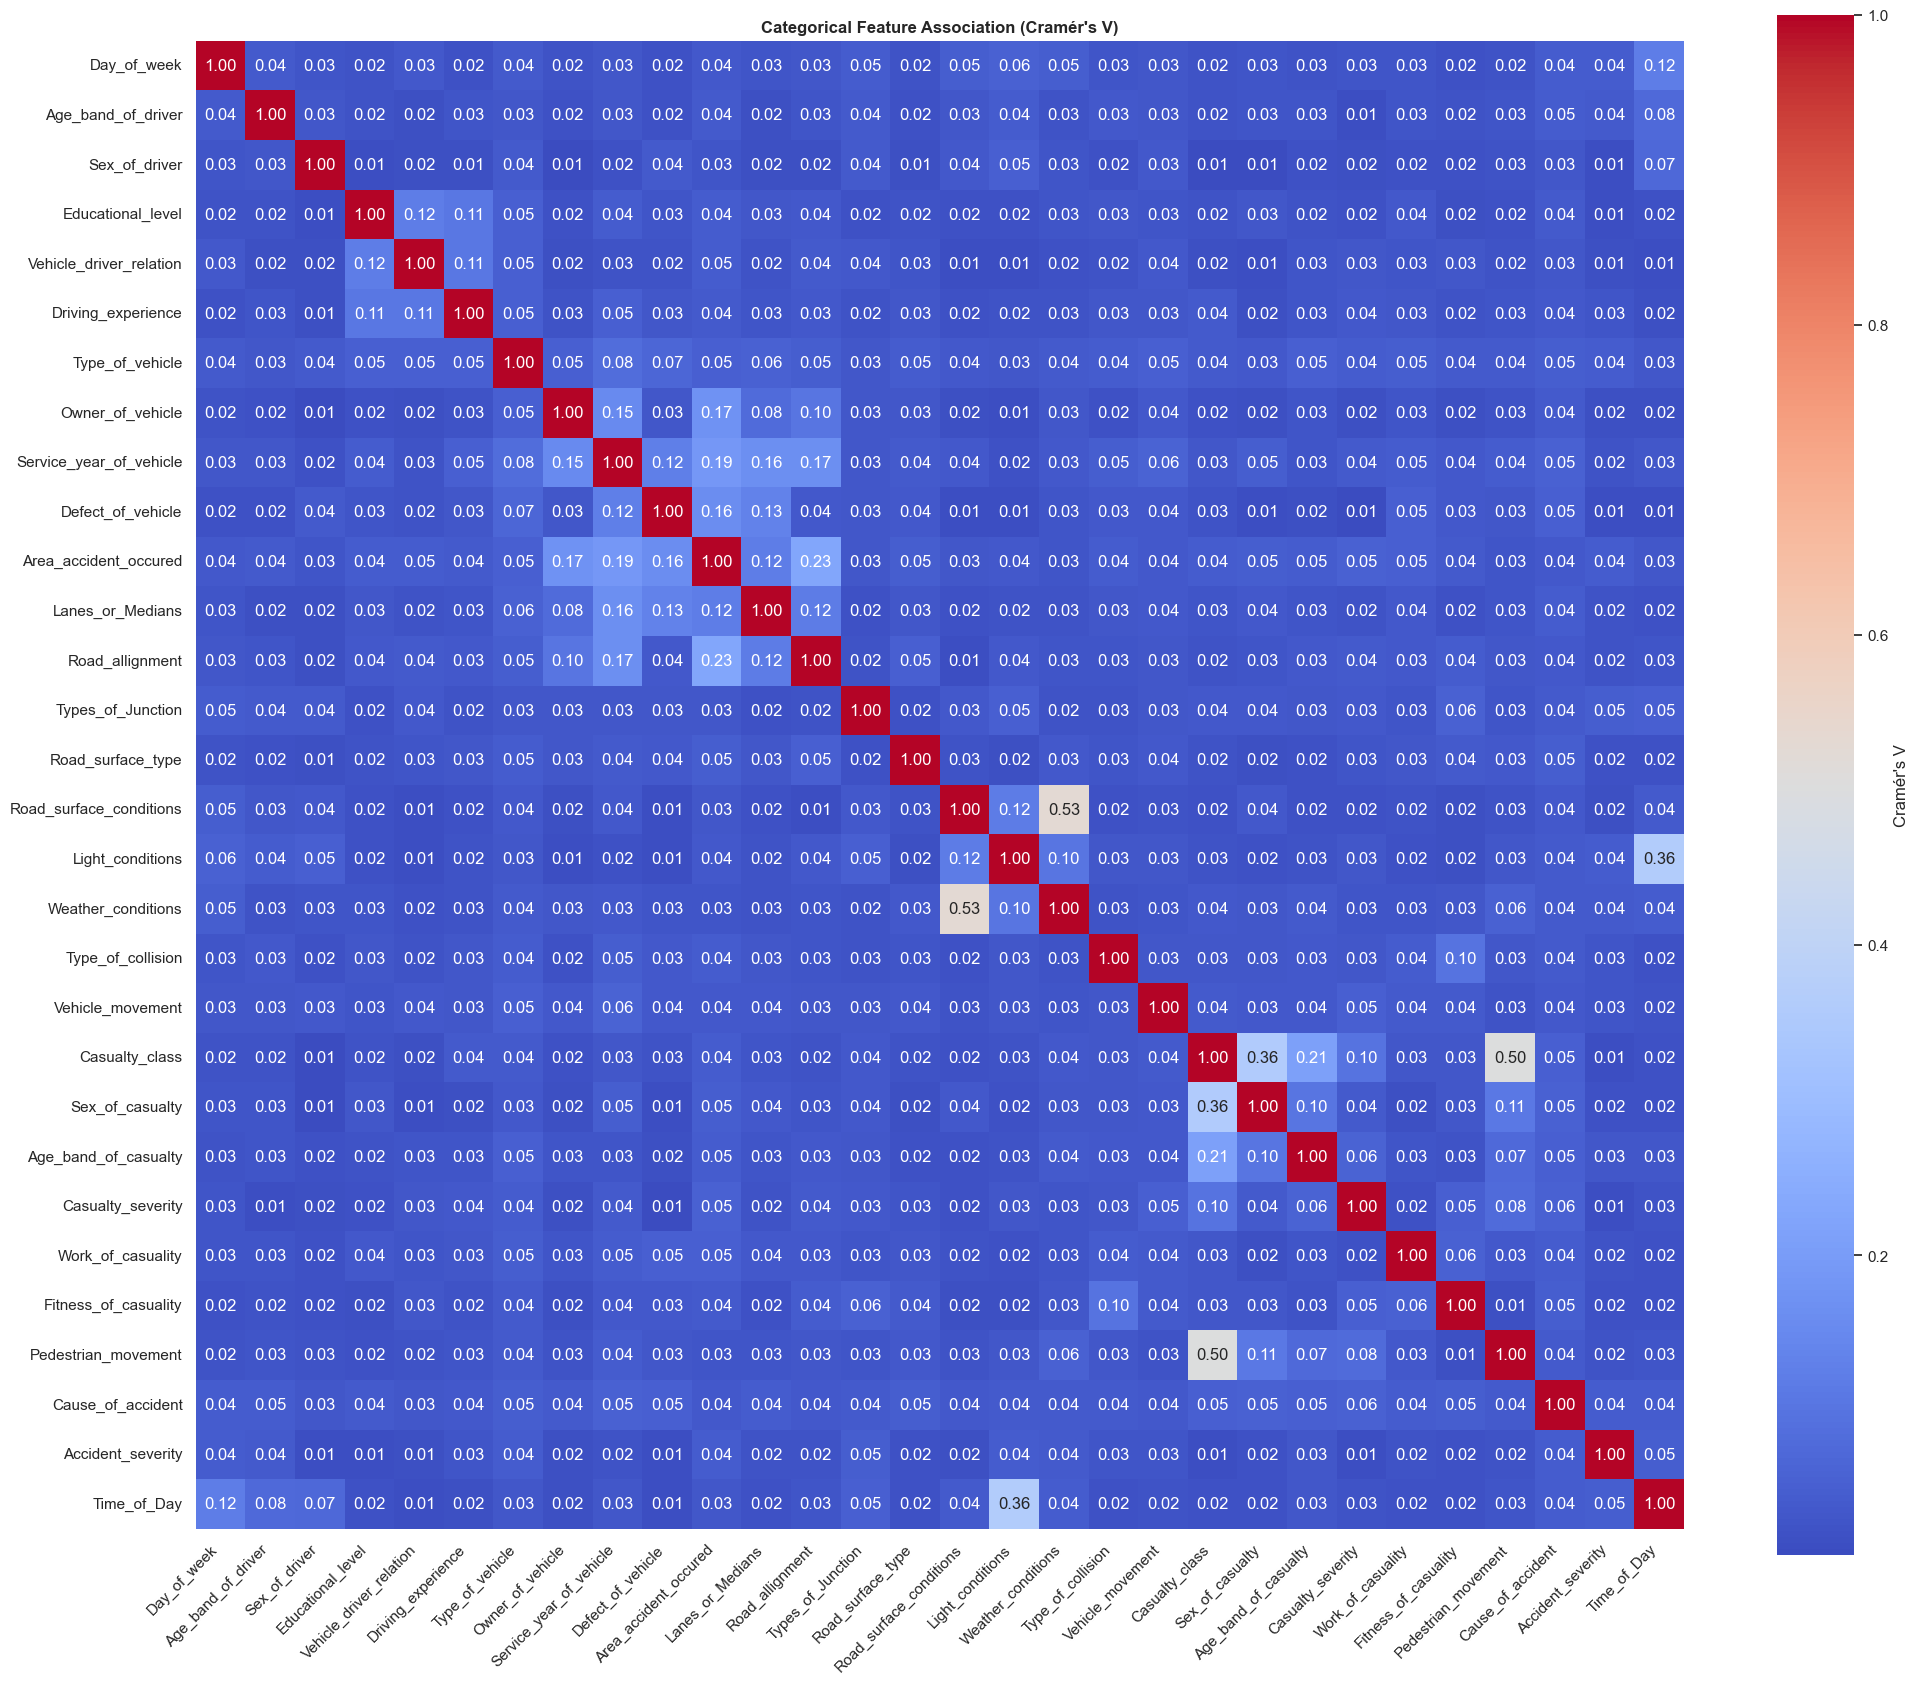

In [95]:
plt.figure(figsize=(24, 20))

sns.heatmap(
    cramers_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={'label': "Cramér's V"}
)

plt.title("Categorical Feature Association (Cramér's V)", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Some key insights

## Top Causes of severe accidents

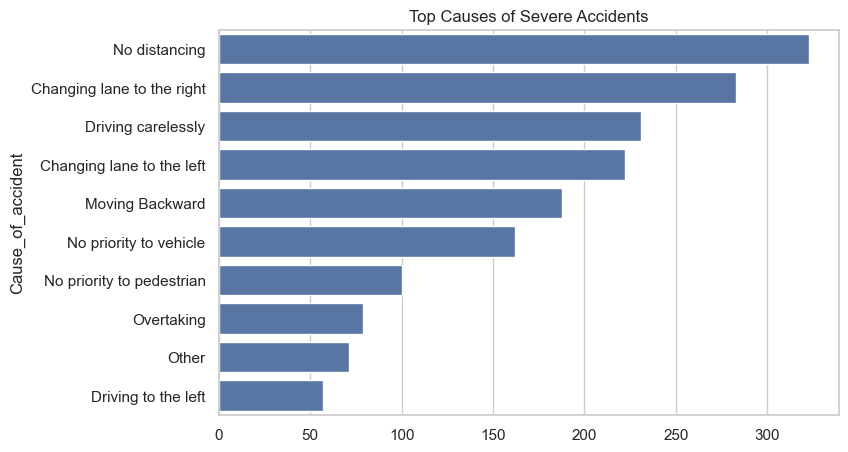

In [91]:
severe_accidents = df[df['Accident_severity'].isin(['Fatal injury', 'Serious Injury'])]

top_causes = severe_accidents['Cause_of_accident'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_causes.values, y=top_causes.index)
plt.title('Top Causes of Severe Accidents')
plt.show()

## Environmental Interactions

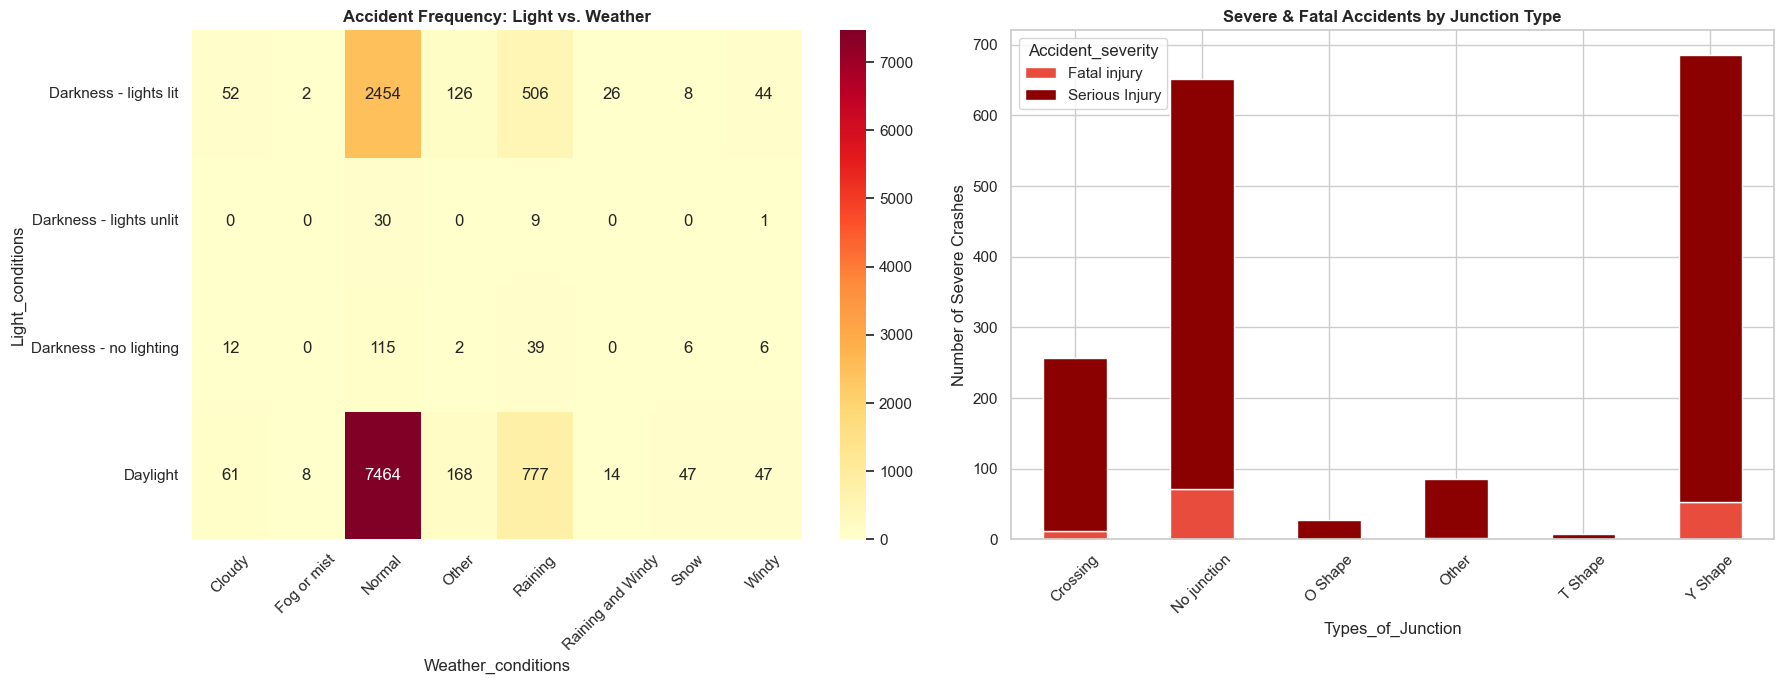

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap 1: Light Conditions vs. Weather Conditions
light_weather = pd.crosstab(df['Light_conditions'], df['Weather_conditions'])
sns.heatmap(light_weather, cmap='YlOrRd', annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Accident Frequency: Light vs. Weather', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap 2: Serious/Fatal Accidents by Junction Type
# Filter only for severe accidents to find infrastructure weaknesses
severe_mask = df['Accident_severity'].isin(['Serious Injury', 'Fatal injury'])
severe_accidents = df[severe_mask]

junction_severity = pd.crosstab(severe_accidents['Types_of_Junction'], severe_accidents['Accident_severity'])
junction_severity.plot(kind='bar', stacked=True, color=['#e74c3c', '#8b0000'], ax=axes[1])
axes[1].set_title('Severe & Fatal Accidents by Junction Type', fontweight='bold')
axes[1].set_ylabel('Number of Severe Crashes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Driver Behaviour and Demographics

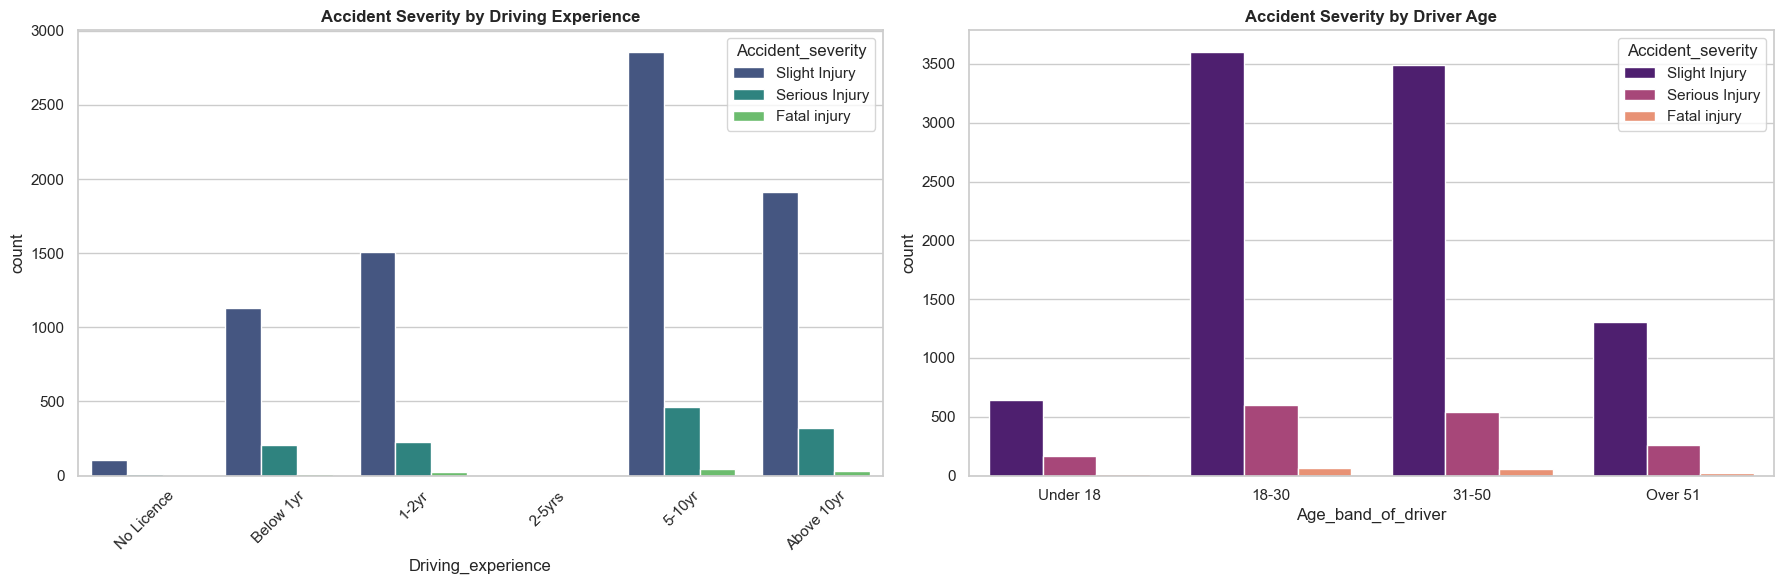

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Driving Experience vs. Accident Severity
sns.countplot(data=df, x='Driving_experience', hue='Accident_severity', ax=axes[0], palette='viridis',
              order=['No Licence', 'Below 1yr', '1-2yr', '2-5yrs', '5-10yr', 'Above 10yr'])
axes[0].set_title('Accident Severity by Driving Experience', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Age Band of Driver
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity', ax=axes[1], palette='magma',
              order=['Under 18', '18-30', '31-50', 'Over 51'])
axes[1].set_title('Accident Severity by Driver Age', fontweight='bold')

plt.tight_layout()
plt.show()

## Root Cause Analysis for Policy Makers


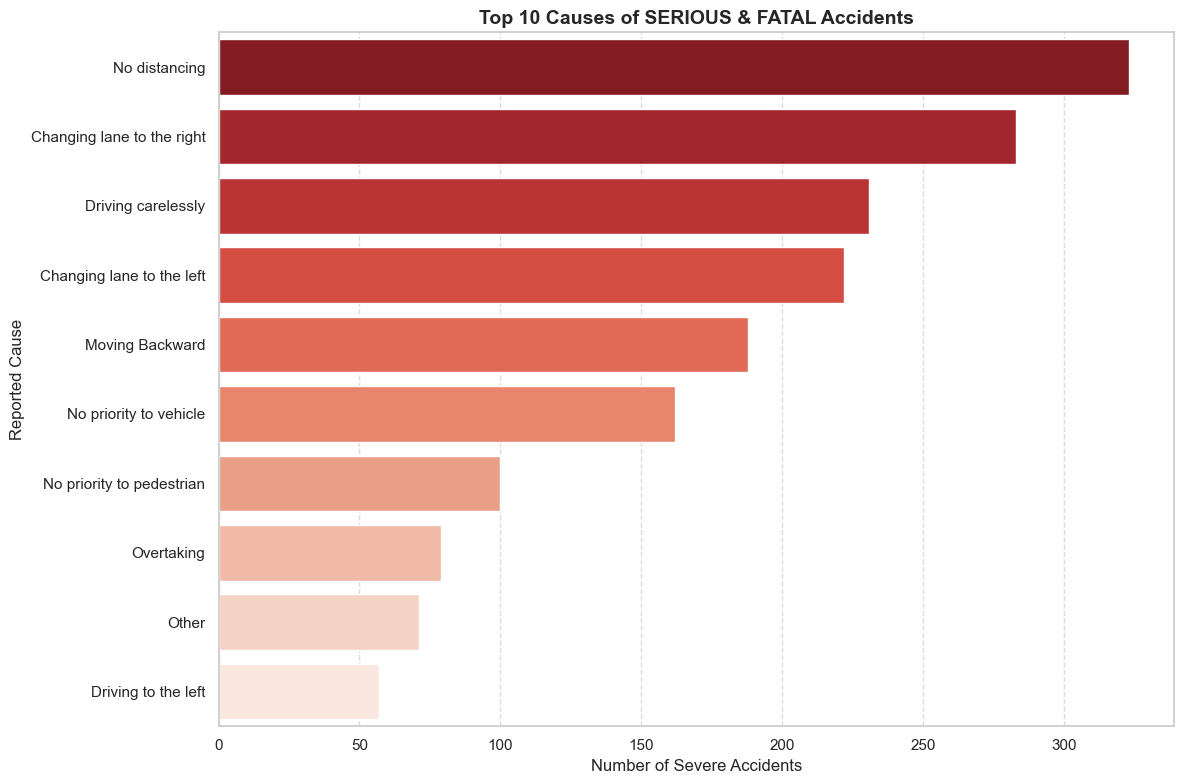

In [74]:
plt.figure(figsize=(12, 8))

# Get the top 10 causes for SEVERE accidents only
top_severe_causes = severe_accidents['Cause_of_accident'].value_counts().head(10)

sns.barplot(x=top_severe_causes.values, y=top_severe_causes.index, palette='Reds_r')
plt.title('Top 10 Causes of SERIOUS & FATAL Accidents', fontweight='bold', fontsize=14)
plt.xlabel('Number of Severe Accidents')
plt.ylabel('Reported Cause')

# Add a vertical grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()